In [1]:
# ============================================
# TASK 2 - EXPLORATORY DATA ANALYSIS
# ============================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")


In [2]:
# ============================================
# FIND TASK 1 CLEANED DATASET
# ============================================

candidate_paths = [
    "../../task1_air_quality/outputs/air_quality_cleaned.csv",
    "../../task1_air_quality/processed/air_quality_cleaned.csv",
    "../../outputs/air_quality_cleaned.csv",
    "../../processed/air_quality_cleaned.csv",
    "../outputs/air_quality_cleaned.csv",
    "../processed/air_quality_cleaned.csv",
]

input_path = next(
    (path for path in candidate_paths if os.path.isfile(path)),
    None
)

if input_path is None:
    raise FileNotFoundError(
        "\nCould not find air_quality_cleaned.csv.\n\n"
        "Expected it in one of these locations:\n"
        + "\n".join(candidate_paths)
    )

print("Dataset found:")
print(os.path.abspath(input_path))

Dataset found:
C:\Users\harsh\YuvaIntern_Data_Science_Project\task1_air_quality\outputs\air_quality_cleaned.csv


In [3]:
# ============================================
# LOAD DATA
# ============================================

df = pd.read_csv(input_path)

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully.
Rows    : 9,357
Columns : 13

Columns:
['Datetime', 'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


In [4]:
# ============================================
# BASIC DATA VALIDATION
# ============================================

required_columns = {"Datetime"}

missing_required = required_columns - set(df.columns)

if missing_required:
    raise ValueError(
        f"Required column(s) missing: {missing_required}"
    )

# Convert datetime
df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Invalid datetime:", df["Datetime"].isna().sum())
print("Remaining -200 values:", (df == -200).sum().sum())

Shape: (9357, 13)
Missing values: 0
Duplicate rows: 0
Invalid datetime: 0
Remaining -200 values: 0


In [5]:
# ============================================
# DATASET INFORMATION
# ============================================

print("DATA TYPES")
print("=" * 60)

print(df.dtypes)

print("\nDATASET INFO")
print("=" * 60)

df.info()

DATA TYPES
Datetime         datetime64[us]
CO(GT)                  float64
PT08.S1(CO)             float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
dtype: object

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Datetime       9357 non-null   datetime64[us]
 1   CO(GT)         9357 non-null   float64       
 2   PT08.S1(CO)    9357 non-null   float64       
 3   C6H6(GT)       9357 non-null   float64       
 4   PT08.S2(NMHC)  9357 non-null   float64       
 5   NOx(GT)        9357 non-null   float64       
 6   PT08.S3(NOx)   9357 non-null   float

In [7]:
# ============================================
# IDENTIFY NUMERICAL VARIABLES
# ============================================

numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical columns:")
for col in numeric_cols:
    print("-", col)

print(f"\nTotal numerical variables: {len(numeric_cols)}")

Numerical columns:
- CO(GT)
- PT08.S1(CO)
- C6H6(GT)
- PT08.S2(NMHC)
- NOx(GT)
- PT08.S3(NOx)
- NO2(GT)
- PT08.S4(NO2)
- PT08.S5(O3)
- T
- RH
- AH

Total numerical variables: 12


In [8]:
# ============================================
# DESCRIPTIVE STATISTICS
# ============================================

statistics = df[numeric_cols].describe().T

statistics["median"] = df[numeric_cols].median()

statistics = statistics[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
]

statistics = statistics.round(2)

print("Descriptive Statistics:")
print(statistics)

Descriptive Statistics:
                count     mean  median     std     min      25%     50%     75%      max
CO(GT)         9357.0     2.09     1.8    1.32    0.10     1.20     1.8     2.6    11.90
PT08.S1(CO)    9357.0  1098.39  1063.0  212.91  647.00   941.00  1063.0  1221.0  2040.00
C6H6(GT)       9357.0    10.01     8.2    7.31    0.10     4.60     8.2    13.6    63.70
PT08.S2(NMHC)  9357.0   937.97   909.0  261.63  383.00   743.00   909.0  1105.0  2214.00
NOx(GT)        9357.0   235.18   180.0  195.09    2.00   112.00   180.0   284.0  1479.00
PT08.S3(NOx)   9357.0   834.34   806.0  251.81  322.00   666.00   806.0   960.0  2683.00
NO2(GT)        9357.0   112.37   109.0   43.95    2.00    86.00   109.0   133.0   340.00
PT08.S4(NO2)   9357.0  1456.53  1463.0  339.37  551.00  1242.00  1463.0  1662.0  2775.00
PT08.S5(O3)    9357.0  1020.56   963.0  390.78  221.00   742.00   963.0  1255.0  2523.00
T              9357.0    18.30    17.8    8.66   -1.90    12.00    17.8    24.1    44.

In [9]:
# ============================================
# MISSING VALUE ANALYSIS
# ============================================

missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (
        df.isna().mean() * 100
    ).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
]

if missing_summary.empty:
    print("No missing values found.")
else:
    print("Missing values:")
    print(missing_summary)


No missing values found.


In [10]:
# ============================================
# OUTLIER ANALYSIS - IQR METHOD
# ============================================

outlier_records = []

for col in numeric_cols:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    )

    count = int(mask.sum())

    outlier_records.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": count,
        "Outlier Percentage": count / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_records)

outlier_summary["Outlier Percentage"] = (
    outlier_summary["Outlier Percentage"].round(2)
)

outlier_summary = outlier_summary.sort_values(
    "Outlier Count",
    ascending=False
)

print(outlier_summary.to_string(index=False))

     Variable        Q1        Q3      IQR  Lower Bound  Upper Bound  Outlier Count  Outlier Percentage
      NOx(GT)  112.0000  284.0000 172.0000   -146.00000    542.00000            778                8.31
       CO(GT)    1.2000    2.6000   1.4000     -0.90000      4.70000            454                4.85
      NO2(GT)   86.0000  133.0000  47.0000     15.50000    203.50000            380                4.06
     C6H6(GT)    4.6000   13.6000   9.0000     -8.90000     27.10000            286                3.06
 PT08.S3(NOx)  666.0000  960.0000 294.0000    225.00000   1401.00000            278                2.97
  PT08.S1(CO)  941.0000 1221.0000 280.0000    521.00000   1641.00000            145                1.55
  PT08.S5(O3)  742.0000 1255.0000 513.0000    -27.50000   2024.50000            131                1.40
 PT08.S4(NO2) 1242.0000 1662.0000 420.0000    612.00000   2292.00000            131                1.40
PT08.S2(NMHC)  743.0000 1105.0000 362.0000    200.00000   1648.0

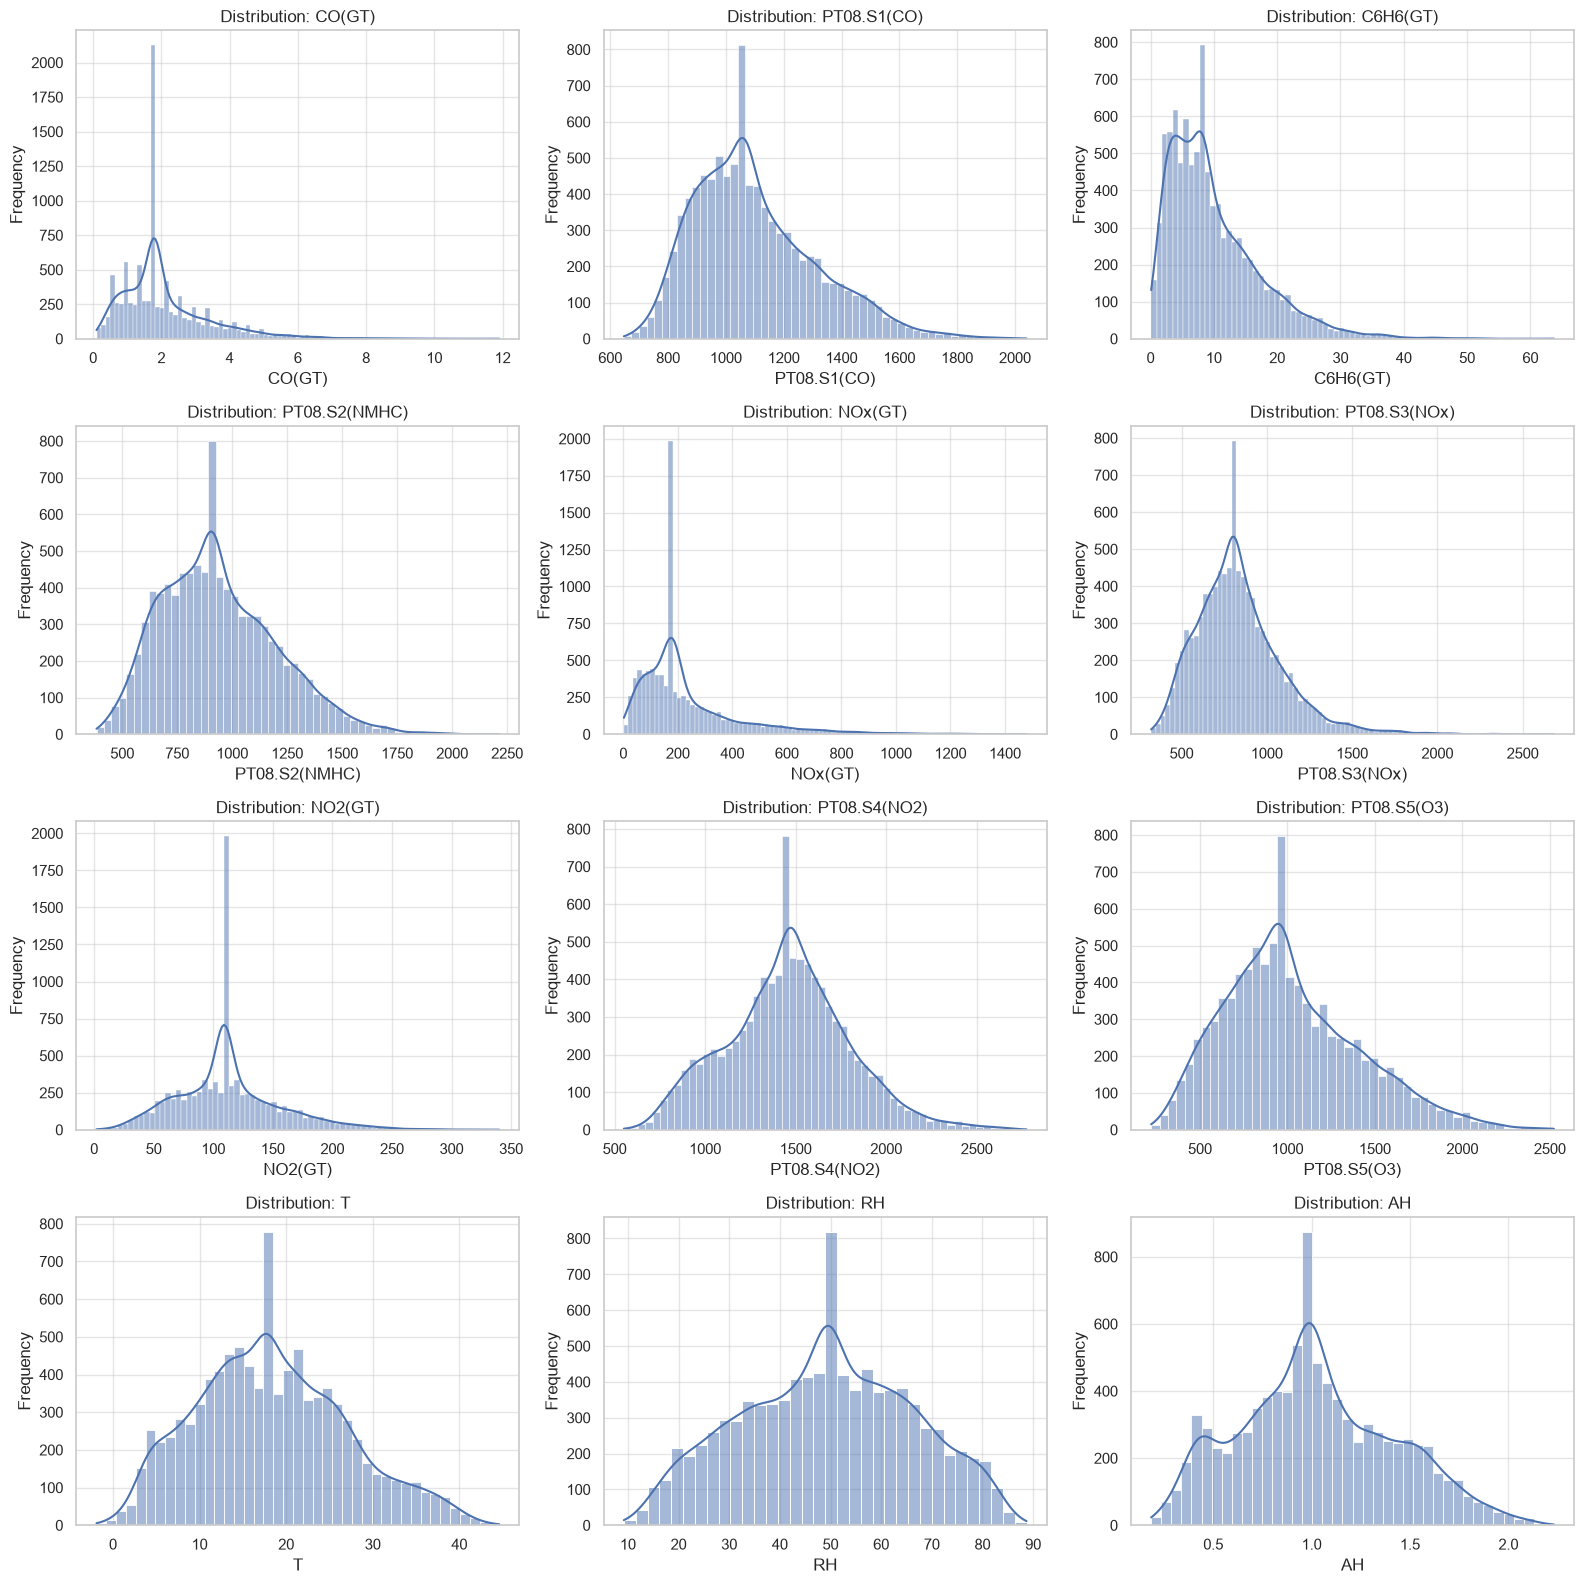

In [11]:
# ============================================
# DISTRIBUTION ANALYSIS
# ============================================

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_cols):

    sns.histplot(
        df[col],
        kde=True,
        ax=ax
    )

    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

# Hide unused axes
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


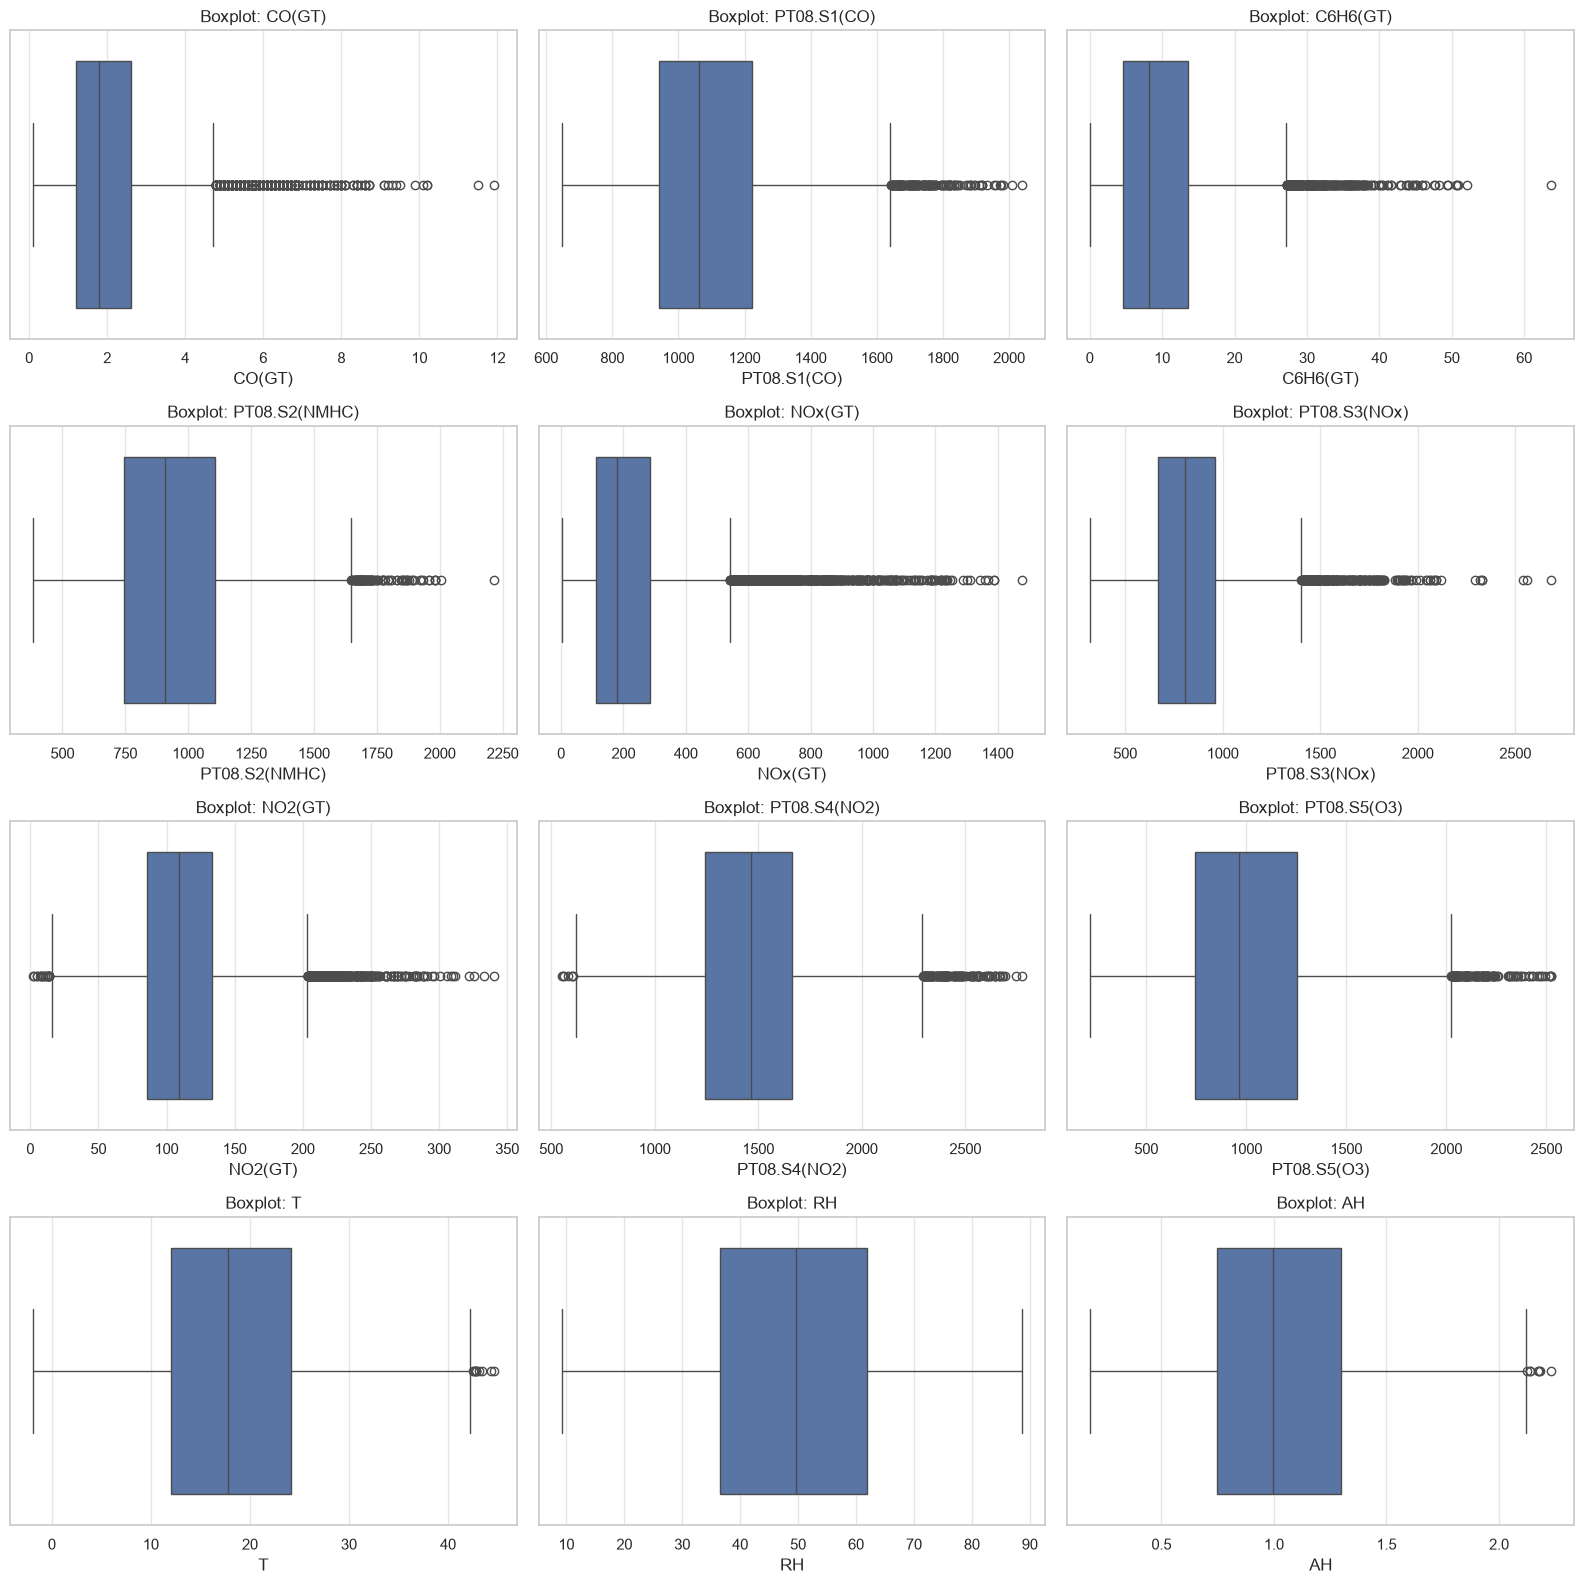

In [12]:
# ============================================
# BOXPLOT ANALYSIS
# ============================================

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_cols):

    sns.boxplot(
        x=df[col],
        ax=ax
    )

    ax.set_title(f"Boxplot: {col}")
    ax.set_xlabel(col)

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [13]:
# ============================================
# CORRELATION ANALYSIS
# ============================================

correlation_matrix = df[numeric_cols].corr()

print("Correlation matrix:")
print(correlation_matrix.round(2))

Correlation matrix:
               CO(GT)  PT08.S1(CO)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  \
CO(GT)           1.00         0.78      0.81           0.80     0.78         -0.62     0.66          0.55   
PT08.S1(CO)      0.78         1.00      0.88           0.89     0.62         -0.77     0.56          0.68   
C6H6(GT)         0.81         0.88      1.00           0.98     0.62         -0.73     0.53          0.76   
PT08.S2(NMHC)    0.80         0.89      0.98           1.00     0.61         -0.80     0.56          0.78   
NOx(GT)          0.78         0.62      0.62           0.61     1.00         -0.57     0.76          0.20   
PT08.S3(NOx)    -0.62        -0.77     -0.73          -0.80    -0.57          1.00    -0.57         -0.54   
NO2(GT)          0.66         0.56      0.53           0.56     0.76         -0.57     1.00          0.14   
PT08.S4(NO2)     0.55         0.68      0.76           0.78     0.20         -0.54     0.14          1.00   

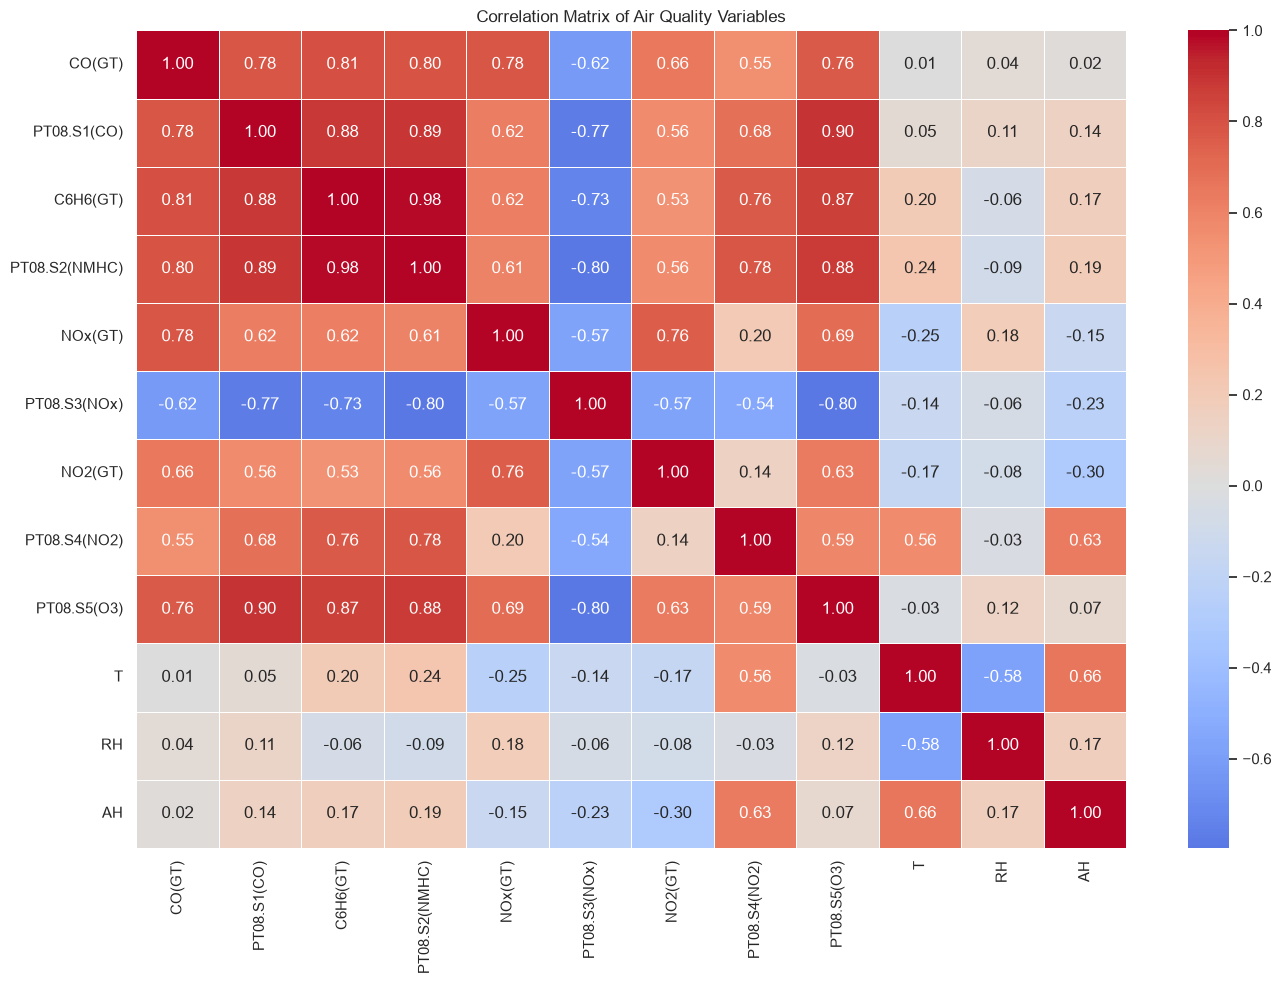

In [14]:
# ============================================
# CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Air Quality Variables")
plt.tight_layout()

plt.show()

In [15]:
# ============================================
# STRONGEST CORRELATIONS
# ============================================

corr_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Variable 1",
    "Variable 2",
    "Correlation"
]

corr_pairs["Absolute Correlation"] = (
    corr_pairs["Correlation"].abs()
)

strongest_correlations = (
    corr_pairs
    .sort_values(
        "Absolute Correlation",
        ascending=False
    )
    .head(10)
)

print(strongest_correlations.to_string(index=False))

   Variable 1    Variable 2  Correlation  Absolute Correlation
     C6H6(GT) PT08.S2(NMHC)     0.981596              0.981596
  PT08.S1(CO)   PT08.S5(O3)     0.899417              0.899417
  PT08.S1(CO) PT08.S2(NMHC)     0.892989              0.892989
  PT08.S1(CO)      C6H6(GT)     0.883871              0.883871
PT08.S2(NMHC)   PT08.S5(O3)     0.880633              0.880633
     C6H6(GT)   PT08.S5(O3)     0.865711              0.865711
       CO(GT)      C6H6(GT)     0.808857              0.808857
       CO(GT) PT08.S2(NMHC)     0.795959              0.795959
PT08.S2(NMHC)  PT08.S3(NOx)    -0.795792              0.795792
 PT08.S3(NOx)   PT08.S5(O3)    -0.795337              0.795337


In [16]:
# ============================================
# TEMPORAL FEATURES
# ============================================

eda_df = df.copy()

eda_df["Year"] = eda_df["Datetime"].dt.year
eda_df["Month"] = eda_df["Datetime"].dt.month
eda_df["Hour"] = eda_df["Datetime"].dt.hour
eda_df["DayOfWeek"] = eda_df["Datetime"].dt.dayofweek

print(
    eda_df[
        ["Datetime", "Year", "Month", "Hour", "DayOfWeek"]
    ].head()
)

             Datetime  Year  Month  Hour  DayOfWeek
0 2004-03-10 18:00:00  2004      3    18          2
1 2004-03-10 19:00:00  2004      3    19          2
2 2004-03-10 20:00:00  2004      3    20          2
3 2004-03-10 21:00:00  2004      3    21          2
4 2004-03-10 22:00:00  2004      3    22          2


In [17]:
# ============================================
# TIME RANGE
# ============================================

print("First observation:")
print(eda_df["Datetime"].min())

print("\nLast observation:")
print(eda_df["Datetime"].max())

print("\nUnique dates:")
print(eda_df["Datetime"].dt.date.nunique())

print("\nUnique years:")
print(sorted(eda_df["Year"].unique()))

First observation:
2004-03-10 18:00:00

Last observation:
2005-04-04 14:00:00

Unique dates:
391

Unique years:
[np.int32(2004), np.int32(2005)]


In [21]:
# ============================================
# SAFE HOURLY POLLUTION ANALYSIS
# ============================================

target_pollutants = [
    col for col in [
        "CO(GT)",
        "NOx(GT)",
        "NO2(GT)"
    ]
    if col in eda_df.columns
]

hourly = eda_df.groupby("Hour")[target_pollutants].mean()

print(hourly.round(2))

      CO(GT)  NOx(GT)  NO2(GT)
Hour                          
0       1.79   188.98   104.11
1       1.52   160.59    93.16
2       1.22   127.72    80.43
3       1.07   175.64   107.07
4       1.32    95.85    66.11
5       0.92   100.42    66.83
6       1.08   133.49    77.09
7       1.81   218.22    96.76
8       2.64   318.96   119.32
9       2.78   335.29   127.68
10      2.44   317.41   130.26
11      2.18   288.52   127.34
12      2.11   259.94   122.28
13      2.14   242.58   117.81
14      2.07   234.01   115.38
15      2.01   230.36   116.03
16      2.20   250.07   121.32
17      2.66   290.92   132.22
18      3.20   327.03   140.81
19      3.46   339.00   144.51
20      3.23   326.12   140.21
21      2.48   274.23   127.88
22      1.95   213.78   114.24
23      1.87   195.36   108.20


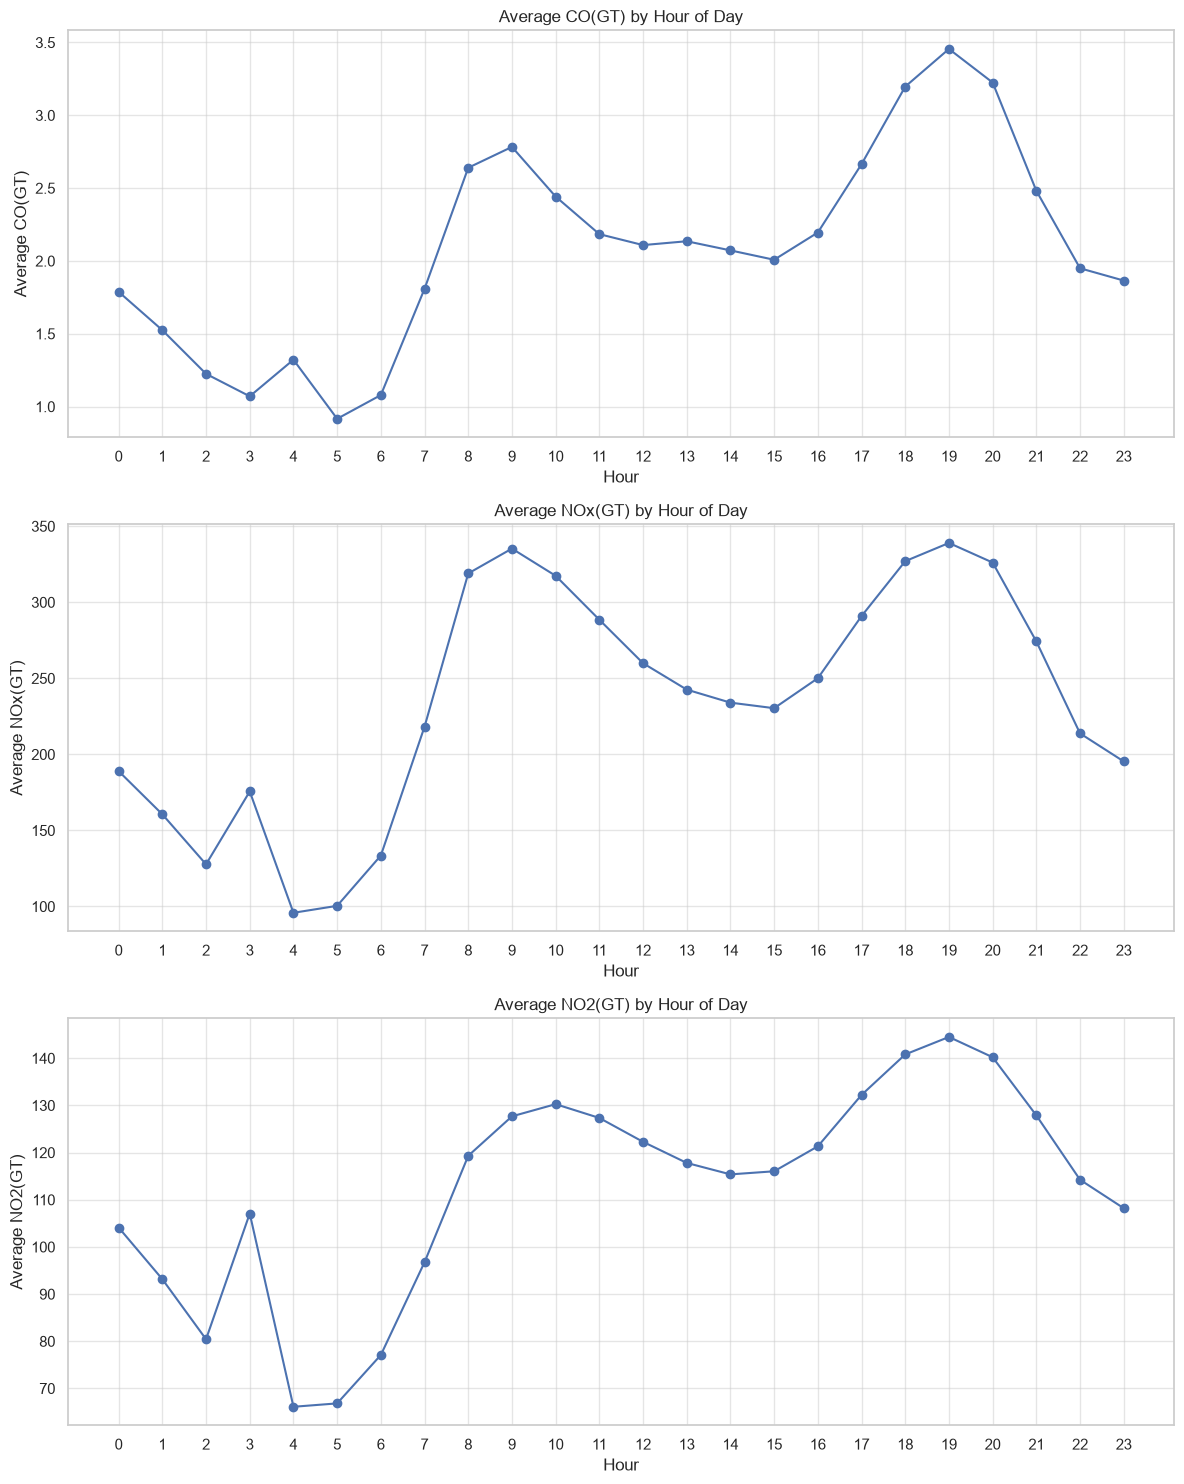

In [22]:
# ============================================
# HOURLY POLLUTION VISUALIZATION
# ============================================

fig, axes = plt.subplots(
    len(target_pollutants),
    1,
    figsize=(12, 5 * len(target_pollutants))
)

if len(target_pollutants) == 1:
    axes = [axes]

for ax, col in zip(axes, target_pollutants):

    ax.plot(
        hourly.index,
        hourly[col],
        marker="o"
    )

    ax.set_title(
        f"Average {col} by Hour of Day"
    )

    ax.set_xlabel("Hour")
    ax.set_ylabel(f"Average {col}")
    ax.set_xticks(range(24))

plt.tight_layout()
plt.show()

In [23]:
# ============================================
# DAILY AGGREGATION
# ============================================

daily = (
    eda_df
    .set_index("Datetime")[numeric_cols]
    .resample("D")
    .mean()
)

print("Daily aggregated dataset:")
print(daily.head())

print("\nDaily shape:")
print(daily.shape)

Daily aggregated dataset:
              CO(GT)  PT08.S1(CO)   C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)     NO2(GT)  PT08.S4(NO2)  \
Datetime                                                                                                       
2004-03-10  1.966667  1316.500000   8.450000     912.333333  132.000   1167.333333  108.833333   1545.500000   
2004-03-11  2.220833  1244.166667   7.979167     851.958333  145.875   1277.250000  100.250000   1522.833333   
2004-03-12  2.720833  1281.666667  12.129167    1008.291667  174.250   1101.875000  115.666667   1627.291667   
2004-03-13  2.658333  1330.666667  10.916667     992.833333  184.250    993.208333  118.458333   1595.791667   
2004-03-14  2.441667  1361.125000   9.637500     943.916667  148.000   1001.291667  110.333333   1602.375000   

            PT08.S5(O3)          T         RH        AH  
Datetime                                                 
2004-03-10  1096.000000  12.033333  54.900000  0.765633  
2004-03-11   88

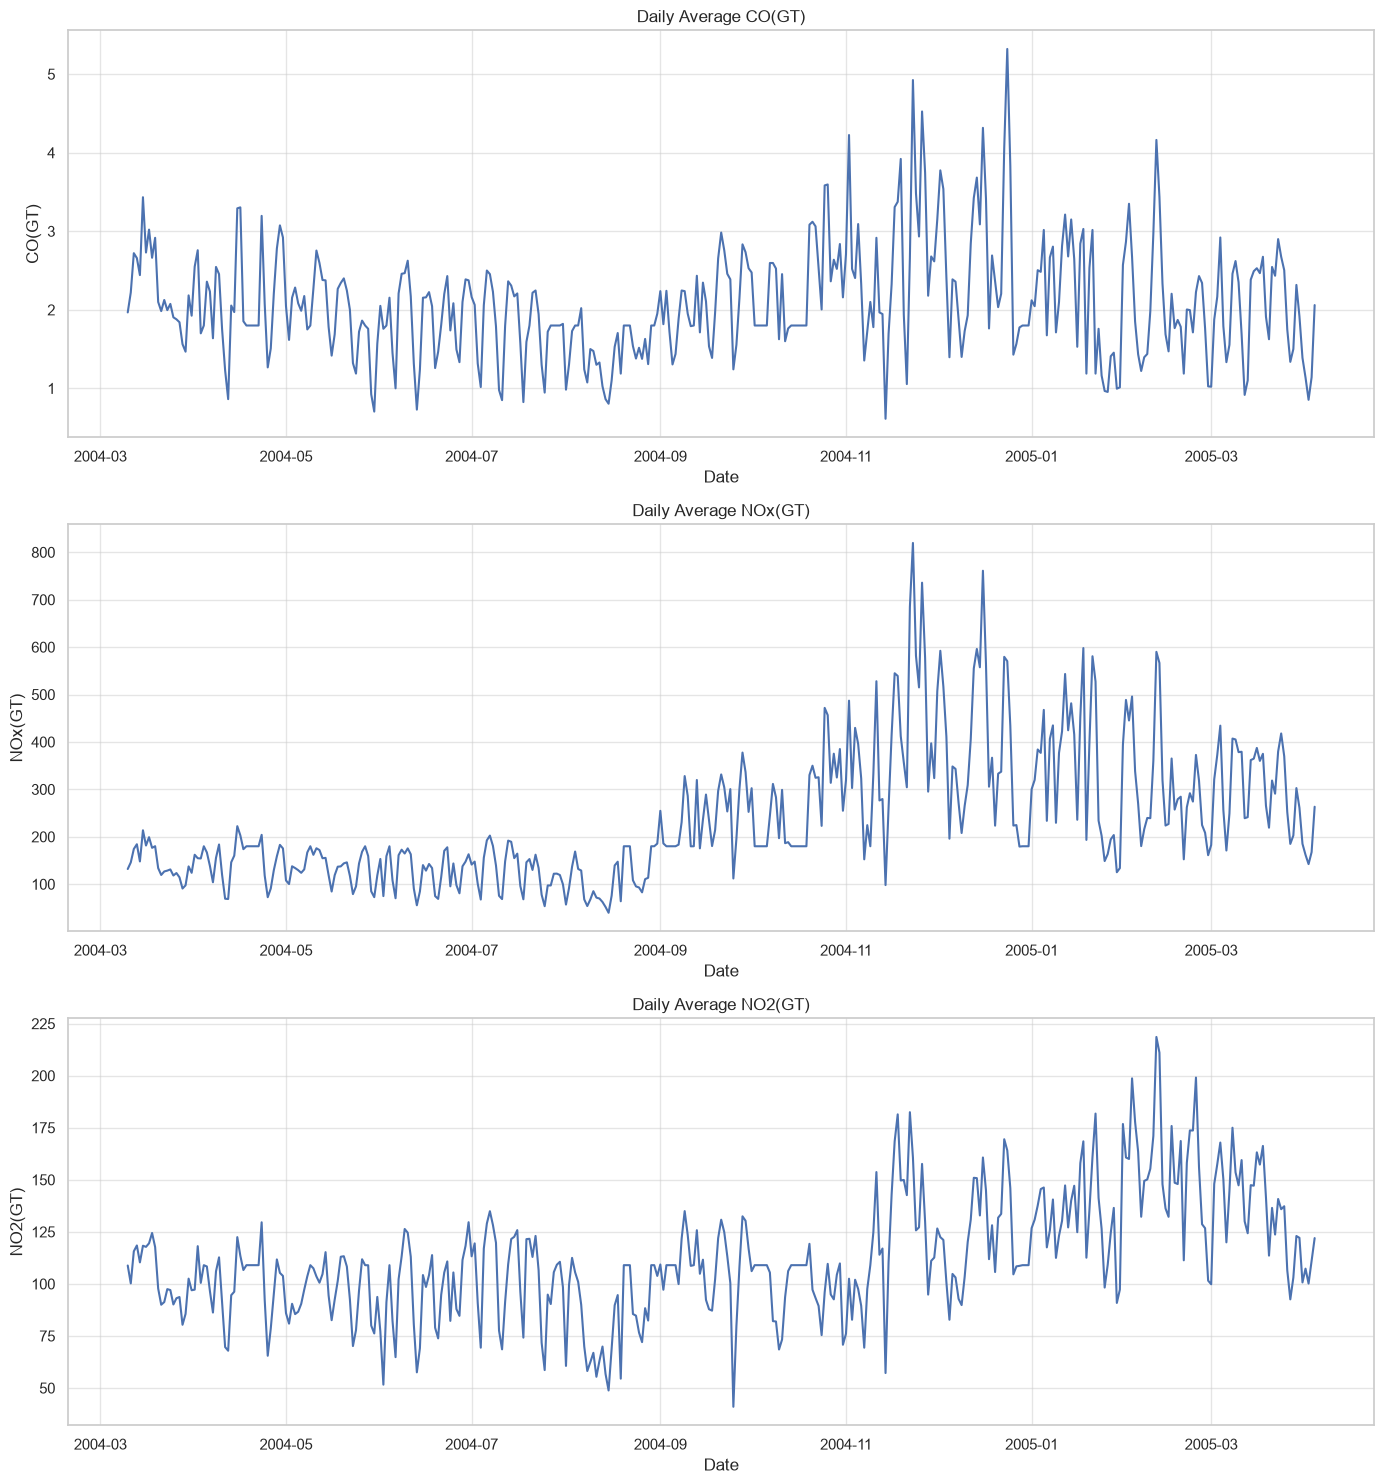

In [24]:
# ============================================
# DAILY POLLUTION TREND
# ============================================

available_pollutants = [
    col for col in [
        "CO(GT)",
        "NOx(GT)",
        "NO2(GT)"
    ]
    if col in daily.columns
]

fig, axes = plt.subplots(
    len(available_pollutants),
    1,
    figsize=(14, 5 * len(available_pollutants))
)

if len(available_pollutants) == 1:
    axes = [axes]

for ax, col in zip(
    axes,
    available_pollutants
):

    ax.plot(
        daily.index,
        daily[col]
    )

    ax.set_title(
        f"Daily Average {col}"
    )

    ax.set_xlabel("Date")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [25]:
# ============================================
# MONTHLY AGGREGATION
# ============================================

monthly = (
    eda_df
    .groupby("Month")[numeric_cols]
    .mean()
)

print(monthly.round(2))

       CO(GT)  PT08.S1(CO)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)      T  \
Month                                                                                                                   
1        2.10      1107.02      8.96         893.17   342.06        793.65   133.60       1178.85      1086.54   9.01   
2        2.09      1084.90      7.58         849.79   309.01        793.56   158.39       1103.45      1024.40   8.32   
3        2.13      1176.77      9.22         907.29   241.52        839.53   122.91       1366.55      1060.74  13.70   
4        2.05      1136.96      9.66         920.86   155.60        927.39   101.69       1537.42       964.17  16.82   
5        1.91      1076.41     10.18         950.30   133.49        944.83    96.26       1598.50       928.86  20.23   
6        1.89      1023.02     10.47         963.35   127.78        895.48    95.58       1708.69       938.95  26.02   
7        1.79      1046.46     1

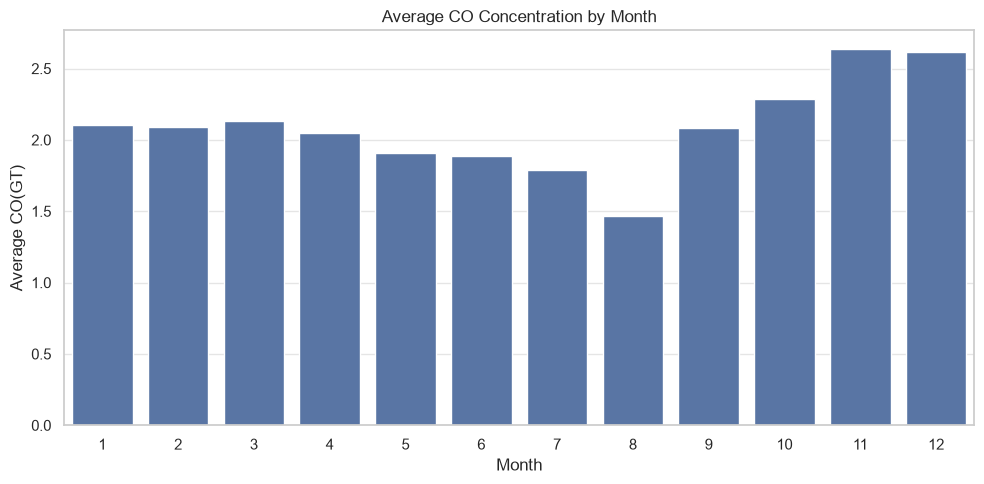

In [26]:
# ============================================
# MONTHLY CO PATTERN
# ============================================

if "CO(GT)" in monthly.columns:

    plt.figure(figsize=(10, 5))

    sns.barplot(
        x=monthly.index,
        y=monthly["CO(GT)"]
    )

    plt.title("Average CO Concentration by Month")
    plt.xlabel("Month")
    plt.ylabel("Average CO(GT)")

    plt.tight_layout()
    plt.show()

In [27]:
# ============================================
# DAY OF WEEK ANALYSIS
# ============================================

day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday = (
    eda_df
    .groupby("DayOfWeek")[target_pollutants]
    .mean()
)

weekday.index = [
    day_names[i]
    for i in weekday.index
]

print(weekday.round(2))

           CO(GT)  NOx(GT)  NO2(GT)
Monday       1.98   226.21   110.09
Tuesday      2.26   250.60   115.76
Wednesday    2.26   252.84   117.87
Thursday     2.33   265.58   118.88
Friday       2.44   269.27   121.32
Saturday     1.85   216.75   107.82
Sunday       1.50   165.47    95.00


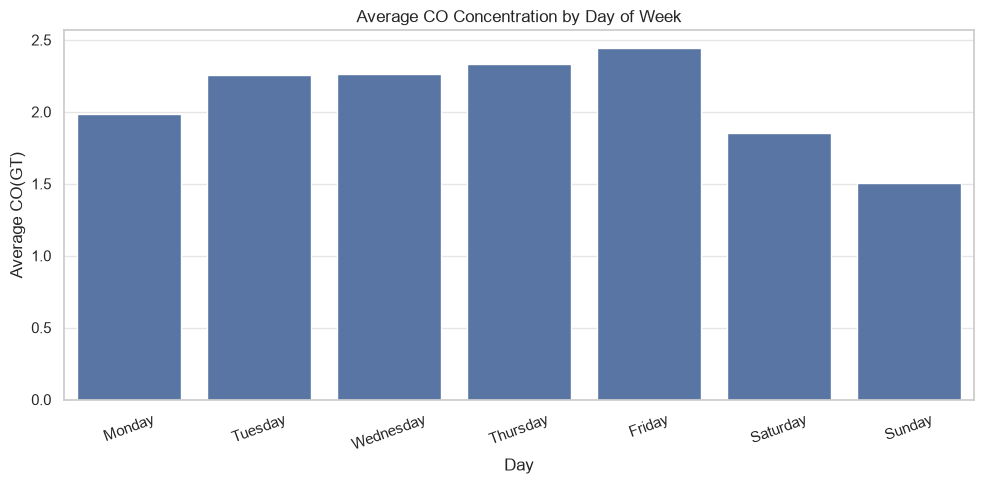

In [28]:
# ============================================
# DAY OF WEEK VISUALIZATION
# ============================================

if "CO(GT)" in weekday.columns:

    plt.figure(figsize=(10, 5))

    sns.barplot(
        x=weekday.index,
        y=weekday["CO(GT)"]
    )

    plt.title("Average CO Concentration by Day of Week")
    plt.xlabel("Day")
    plt.ylabel("Average CO(GT)")

    plt.xticks(rotation=20)

    plt.tight_layout()
    plt.show()

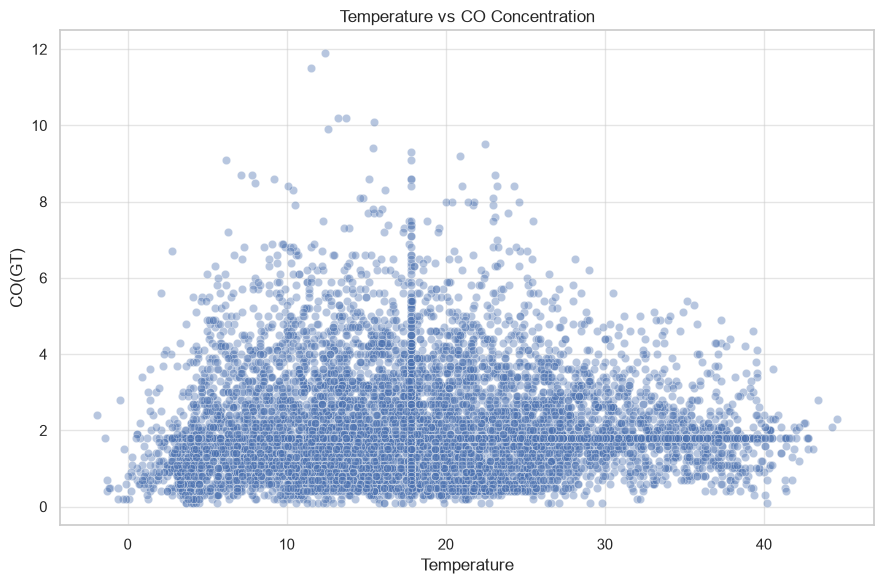

In [29]:
# ============================================
# POLLUTION VS TEMPERATURE
# ============================================

if "T" in eda_df.columns and "CO(GT)" in eda_df.columns:

    plt.figure(figsize=(9, 6))

    sns.scatterplot(
        data=eda_df,
        x="T",
        y="CO(GT)",
        alpha=0.4
    )

    plt.title("Temperature vs CO Concentration")
    plt.xlabel("Temperature")
    plt.ylabel("CO(GT)")

    plt.tight_layout()
    plt.show()

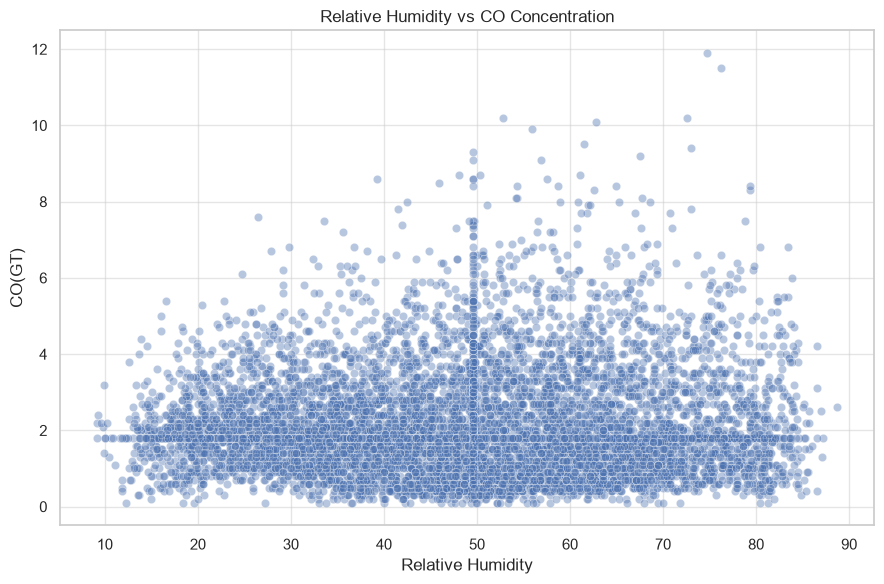

In [30]:
# ============================================
# POLLUTION VS HUMIDITY
# ============================================

if "RH" in eda_df.columns and "CO(GT)" in eda_df.columns:

    plt.figure(figsize=(9, 6))

    sns.scatterplot(
        data=eda_df,
        x="RH",
        y="CO(GT)",
        alpha=0.4
    )

    plt.title("Relative Humidity vs CO Concentration")
    plt.xlabel("Relative Humidity")
    plt.ylabel("CO(GT)")

    plt.tight_layout()
    plt.show()

In [31]:
# ============================================
# HIGHEST POLLUTION OBSERVATIONS
# ============================================

for col in target_pollutants:

    print("\n" + "=" * 60)
    print(f"Highest observations for {col}")
    print("=" * 60)

    top = (
        eda_df[
            ["Datetime", col]
        ]
        .nlargest(10, col)
    )

    print(top.to_string(index=False))


Highest observations for CO(GT)
           Datetime  CO(GT)
2004-11-23 19:00:00    11.9
2004-11-23 20:00:00    11.5
2004-11-17 18:00:00    10.2
2004-11-23 18:00:00    10.2
2004-11-26 18:00:00    10.1
2004-12-13 18:00:00     9.9
2004-10-26 18:00:00     9.5
2004-12-02 19:00:00     9.4
2004-12-14 18:00:00     9.3
2004-11-02 20:00:00     9.2

Highest observations for NOx(GT)
           Datetime  NOx(GT)
2004-12-13 18:00:00   1479.0
2004-11-23 19:00:00   1389.0
2004-11-26 18:00:00   1389.0
2004-11-23 18:00:00   1369.0
2004-11-23 20:00:00   1358.0
2004-11-22 19:00:00   1345.0
2004-12-14 18:00:00   1310.0
2004-11-22 18:00:00   1301.0
2004-11-17 17:00:00   1290.0
2004-12-16 20:00:00   1253.0

Highest observations for NO2(GT)
           Datetime  NO2(GT)
2005-02-11 16:00:00    340.0
2005-02-03 11:00:00    333.0
2005-02-11 17:00:00    326.0
2005-02-03 10:00:00    322.0
2005-02-11 15:00:00    312.0
2005-02-05 09:00:00    310.0
2005-02-03 09:00:00    309.0
2005-02-04 08:00:00    306.0
2005-02-04 

In [32]:
# ============================================
# KEY NUMERICAL FINDINGS
# ============================================

print("=" * 60)
print("KEY EDA FINDINGS")
print("=" * 60)

print(f"\nObservations: {len(eda_df):,}")
print(f"Variables: {len(numeric_cols)}")

print(
    f"Time range: "
    f"{eda_df['Datetime'].min()} → "
    f"{eda_df['Datetime'].max()}"
)

print(
    f"\nMissing values: "
    f"{eda_df.isna().sum().sum()}"
)

print(
    f"Duplicate rows: "
    f"{eda_df.duplicated().sum()}"
)

print(
    f"Remaining -200 values: "
    f"{(eda_df == -200).sum().sum()}"
)

print("\nStrongest correlations:")
print(
    strongest_correlations[
        [
            "Variable 1",
            "Variable 2",
            "Correlation"
        ]
    ].to_string(index=False)
)

print("\nVariables with most IQR-based outliers:")
print(
    outlier_summary[
        [
            "Variable",
            "Outlier Count",
            "Outlier Percentage"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

KEY EDA FINDINGS

Observations: 9,357
Variables: 12
Time range: 2004-03-10 18:00:00 → 2005-04-04 14:00:00

Missing values: 0
Duplicate rows: 0
Remaining -200 values: 0

Strongest correlations:
   Variable 1    Variable 2  Correlation
     C6H6(GT) PT08.S2(NMHC)     0.981596
  PT08.S1(CO)   PT08.S5(O3)     0.899417
  PT08.S1(CO) PT08.S2(NMHC)     0.892989
  PT08.S1(CO)      C6H6(GT)     0.883871
PT08.S2(NMHC)   PT08.S5(O3)     0.880633
     C6H6(GT)   PT08.S5(O3)     0.865711
       CO(GT)      C6H6(GT)     0.808857
       CO(GT) PT08.S2(NMHC)     0.795959
PT08.S2(NMHC)  PT08.S3(NOx)    -0.795792
 PT08.S3(NOx)   PT08.S5(O3)    -0.795337

Variables with most IQR-based outliers:
     Variable  Outlier Count  Outlier Percentage
      NOx(GT)            778                8.31
       CO(GT)            454                4.85
      NO2(GT)            380                4.06
     C6H6(GT)            286                3.06
 PT08.S3(NOx)            278                2.97
  PT08.S1(CO)        

In [33]:
# ============================================
# SAVE TASK 2 OUTPUTS
# ============================================

output_dir = "../outputs"
figure_dir = os.path.join(output_dir, "figures")

os.makedirs(figure_dir, exist_ok=True)

statistics.to_csv(
    os.path.join(output_dir, "descriptive_statistics.csv")
)

correlation_matrix.to_csv(
    os.path.join(output_dir, "correlation_matrix.csv")
)

outlier_summary.to_csv(
    os.path.join(output_dir, "outlier_summary.csv"),
    index=False
)

daily.to_csv(
    os.path.join(output_dir, "daily_average_data.csv")
)

monthly.to_csv(
    os.path.join(output_dir, "monthly_average_data.csv")
)

hourly.to_csv(
    os.path.join(output_dir, "hourly_average_data.csv")
)

weekday.to_csv(
    os.path.join(output_dir, "weekday_average_data.csv")
)

print("Task 2 output tables saved successfully.")
print(
    "Output directory:",
    os.path.abspath(output_dir)
)

Task 2 output tables saved successfully.
Output directory: C:\Users\harsh\YuvaIntern_Data_Science_Project\task2_eda_visualization\outputs


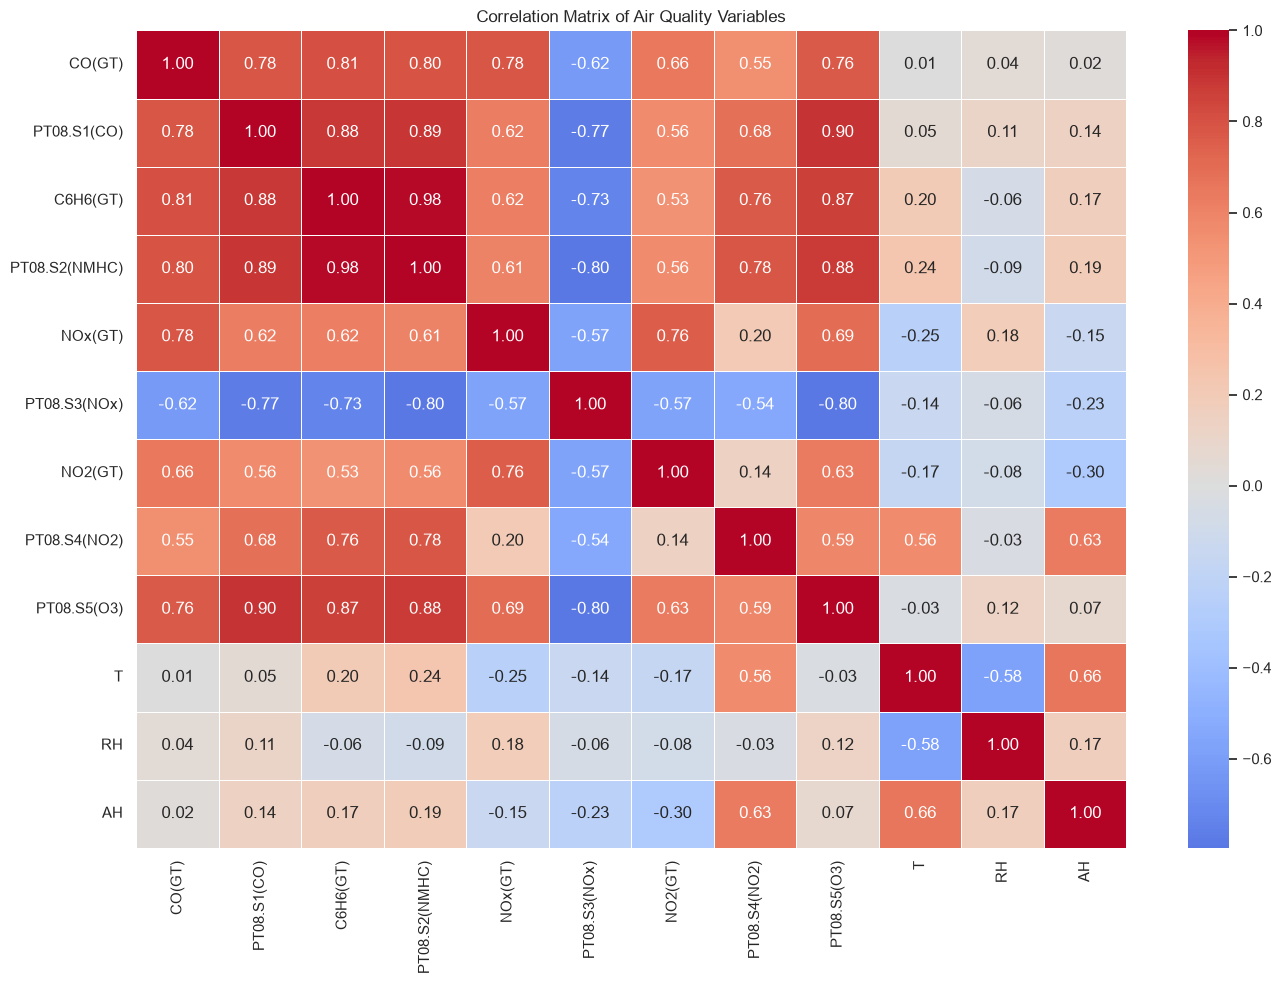

In [34]:
# ============================================
# SAVE CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Air Quality Variables")
plt.tight_layout()

plt.savefig(
    os.path.join(
        figure_dir,
        "correlation_heatmap.png"
    ),
    dpi=200,
    bbox_inches="tight"
)

plt.show()

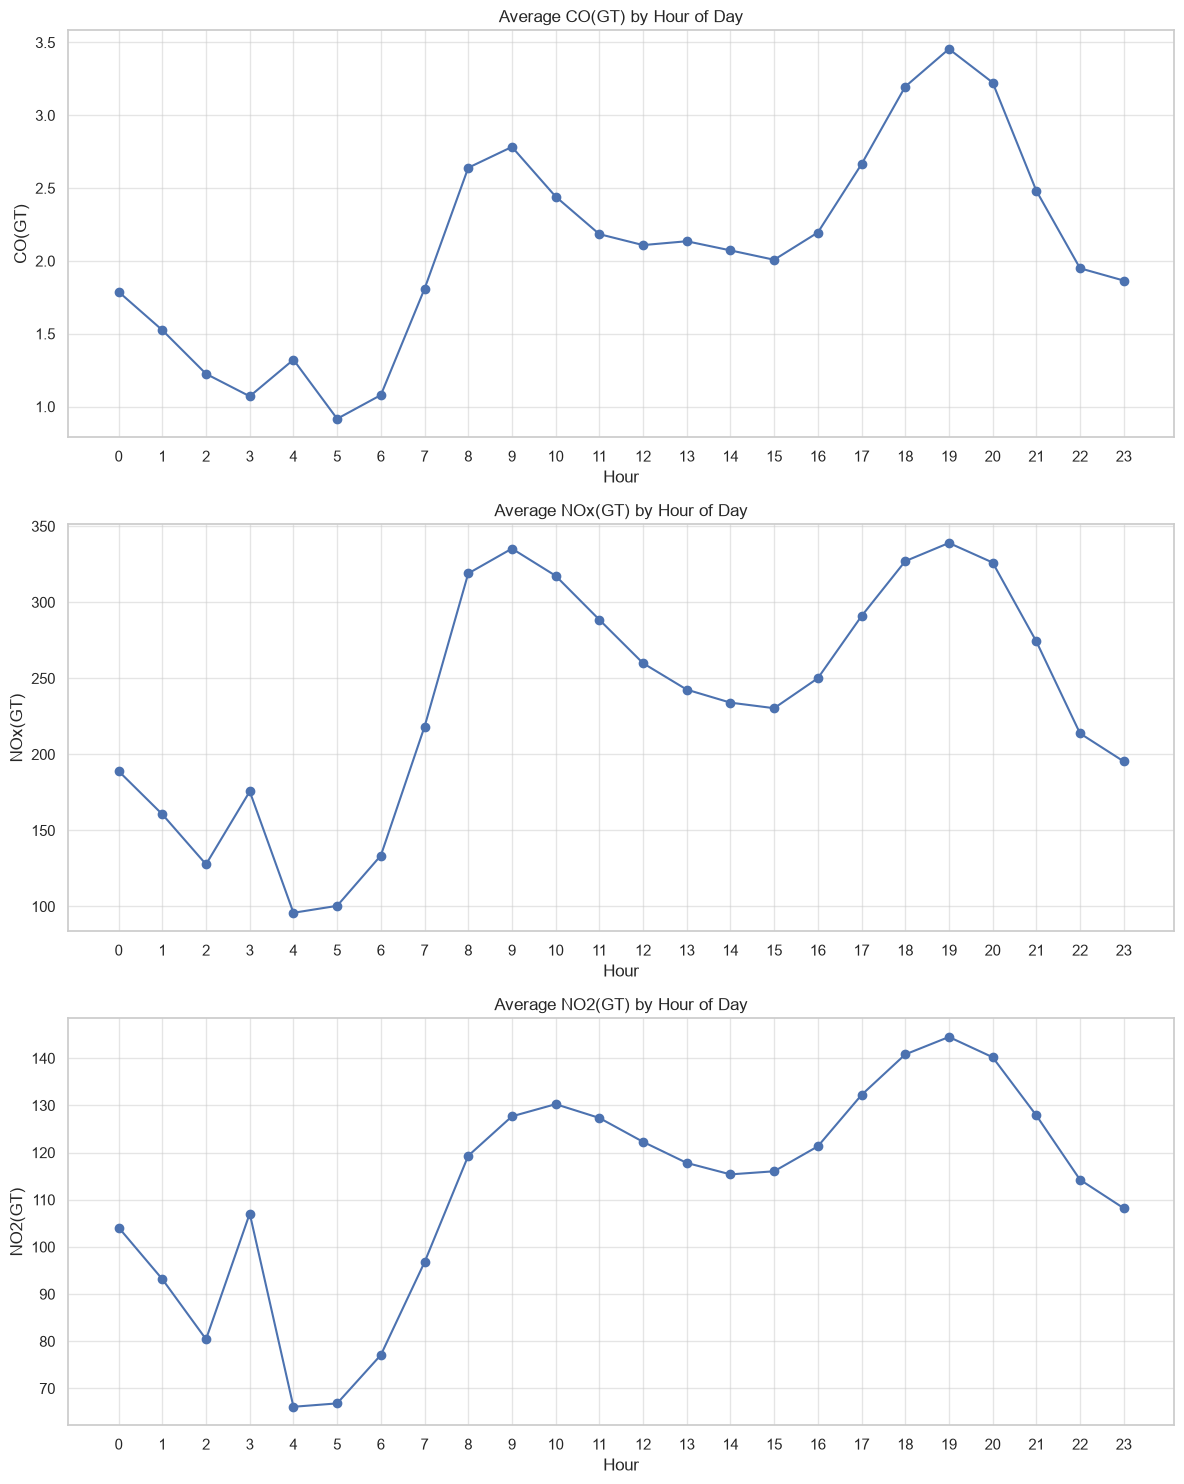

In [35]:
# ============================================
# SAVE HOURLY POLLUTION FIGURE
# ============================================

fig, axes = plt.subplots(
    len(target_pollutants),
    1,
    figsize=(12, 5 * len(target_pollutants))
)

if len(target_pollutants) == 1:
    axes = [axes]

for ax, col in zip(axes, target_pollutants):

    ax.plot(
        hourly.index,
        hourly[col],
        marker="o"
    )

    ax.set_title(
        f"Average {col} by Hour of Day"
    )

    ax.set_xlabel("Hour")
    ax.set_ylabel(col)
    ax.set_xticks(range(24))

plt.tight_layout()

plt.savefig(
    os.path.join(
        figure_dir,
        "hourly_pollution_pattern.png"
    ),
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [36]:
# ============================================
# FINAL TASK 2 VALIDATION
# ============================================

print("=" * 60)
print("TASK 2 FINAL VALIDATION")
print("=" * 60)

checks = {
    "Rows": len(df),
    "Columns": len(df.columns),
    "Missing values": int(df.isna().sum().sum()),
    "Duplicate rows": int(df.duplicated().sum()),
    "Remaining -200 values": int((df == -200).sum().sum()),
    "Invalid datetime": int(df["Datetime"].isna().sum())
}

for name, value in checks.items():
    print(f"{name}: {value}")

print("\nTask 2 EDA completed successfully.")

TASK 2 FINAL VALIDATION
Rows: 9357
Columns: 13
Missing values: 0
Duplicate rows: 0
Remaining -200 values: 0
Invalid datetime: 0

Task 2 EDA completed successfully.
